In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [5]:
Data = pd.read_csv('C:/Users/DANI/Downloads/Data set  vinos/winequality-red.csv')


In [8]:
Data.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.500,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [12]:
Data.shape

(1599, 12)

In [14]:
Data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [18]:
# Características (features)
X = Data.drop('quality', axis=1)

# Objetivo (target)
y = Data['quality']


In [21]:
# Verificar si hay valores nulos en el conjunto de datos
print(Data.isnull().sum())


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [23]:
# Eliminar filas con valores nulos
Data = Data.dropna()


In [25]:
# Calcular el IQR para cada columna numérica
Q1 = Data.quantile(0.25)
Q3 = Data.quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para los valores atípicos
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtrar los datos eliminando valores atípicos
Data_cleaned = Data[~((Data < lower_limit) | (Data > upper_limit)).any(axis=1)]

# Verificar la cantidad de registros después de la limpieza
print(f"Registros antes de la limpieza: {Data.shape[0]}")
print(f"Registros después de la limpieza: {Data_cleaned.shape[0]}")


Registros antes de la limpieza: 1599
Registros después de la limpieza: 1179


(array([ 10.,   0.,  53.,   0., 681.,   0., 638.,   0., 199.,  18.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

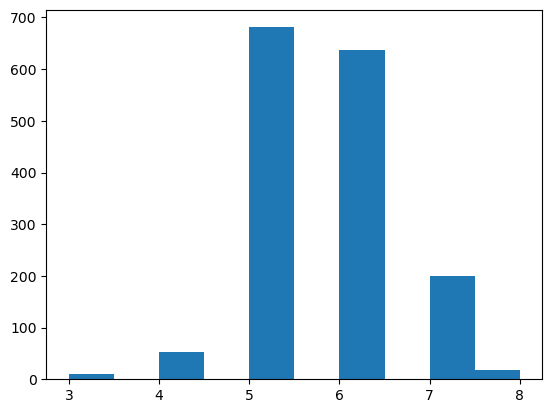

In [29]:

plt.hist(Data.quality)

In [31]:
X = Data_cleaned.drop('quality', axis=1)  # Características
y = Data_cleaned['quality']  # Variable objetivo


In [33]:
from sklearn.model_selection import train_test_split

# Dividir el dataset en conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from sklearn.tree import DecisionTreeClassifier

# Crear el modelo de Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(random_state=42)

# Entrenar el modelo
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hacer predicciones con el conjunto de prueba
y_pred = modelo_arbol.predict(X_test)

# Evaluar precisión
precision = accuracy_score(y_test, y_pred)
print(f'Precisión: {precision}')

# Reporte completo de métricas
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(conf_matrix)


Precisión: 0.635593220338983
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         9
           5       0.68      0.70      0.69       102
           6       0.62      0.64      0.63        99
           7       0.55      0.62      0.58        26

    accuracy                           0.64       236
   macro avg       0.46      0.49      0.48       236
weighted avg       0.62      0.64      0.63       236

Matriz de confusión:
[[ 0  5  3  1]
 [ 0 71 29  2]
 [ 2 24 63 10]
 [ 0  4  6 16]]


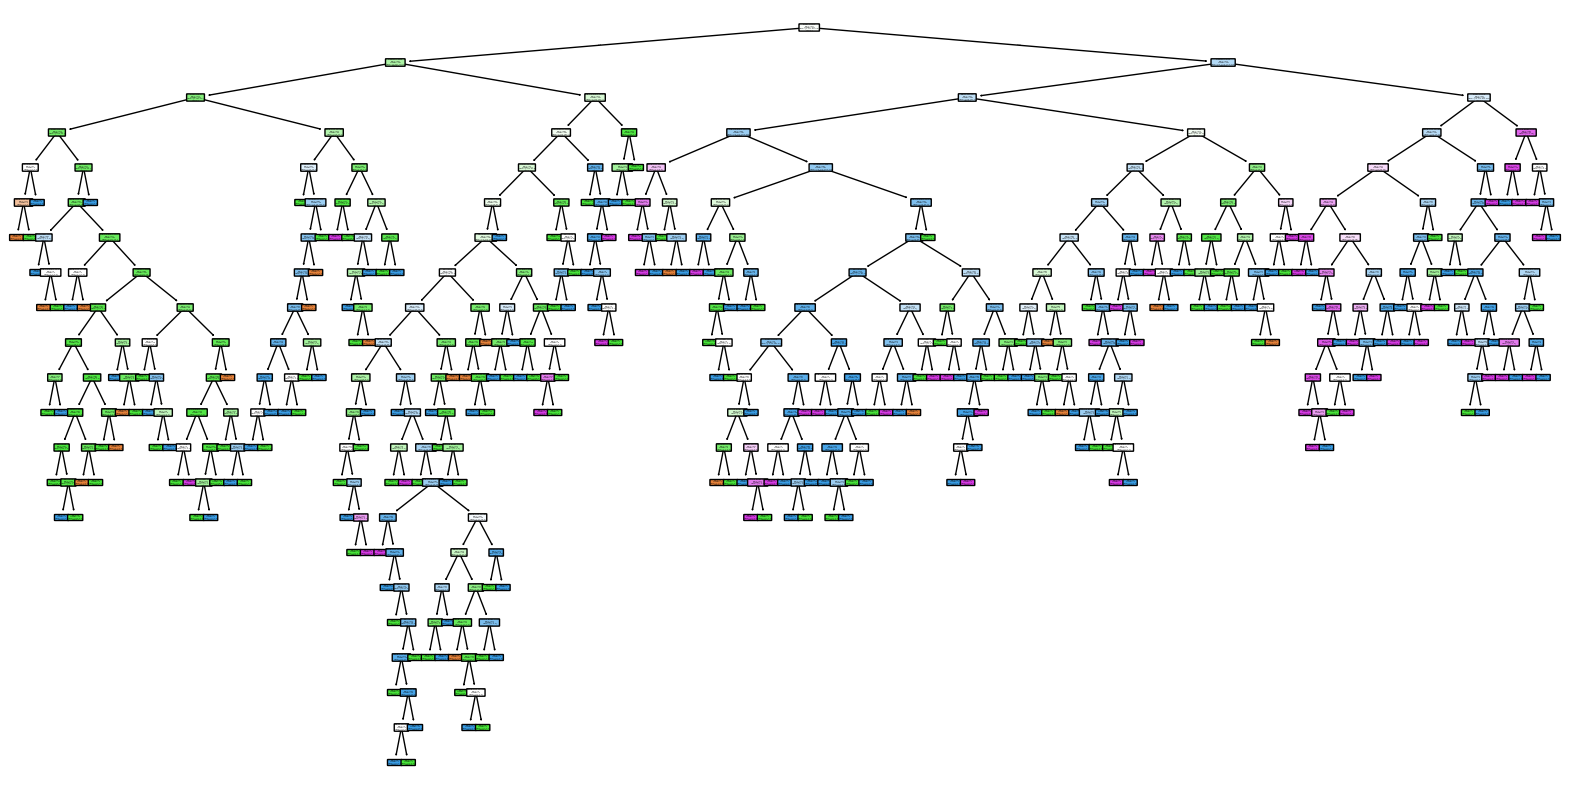

In [39]:
from sklearn.tree import plot_tree

# Graficar el árbol de decisión
plt.figure(figsize=(20,10))
plot_tree(modelo_arbol, filled=True, feature_names=X.columns, class_names=['3', '4', '5', '6', '7', '8'], rounded=True)
plt.show()


In [41]:
modelo_arbol_tuneado = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
modelo_arbol_tuneado.fit(X_train, y_train)
y_pred_tuneado = modelo_arbol_tuneado.predict(X_test)

# Evaluar el modelo ajustado
print(f'Precisión ajustada: {accuracy_score(y_test, y_pred_tuneado)}')
print(classification_report(y_test, y_pred_tuneado))



Precisión ajustada: 0.6228813559322034
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         9
           5       0.63      0.83      0.72       102
           6       0.63      0.53      0.57        99
           7       0.59      0.38      0.47        26

    accuracy                           0.62       236
   macro avg       0.46      0.44      0.44       236
weighted avg       0.60      0.62      0.60       236

